## Stratified K-Fold

### Importing Libraries

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


### Dataset Load

In [5]:
dataset = pd.read_csv('creditcard.csv')

### Spliting Features and Target

In [7]:
X = dataset.drop('Class', axis=1)  
y = dataset['Class']               


### Setting Up Stratified K-Fold

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Initialize model

In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

### Cross validation loop

In [14]:
f1_scores = []

for train_index, test_index in skf.split(X, y):
    # Split into training and testing
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate F1-score
    score = f1_score(y_test, y_pred)
    f1_scores.append(score)

In [15]:
print("F1-scores for each fold:", f1_scores)
print("Average F1-score:", np.mean(f1_scores))

F1-scores for each fold: [0.8248587570621468, 0.875, 0.8764044943820225, 0.8390804597701149, 0.8397790055248618]
Average F1-score: 0.8510245433478293


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.92      0.78      0.84        98

    accuracy                           1.00     56961
   macro avg       0.96      0.89      0.92     56961
weighted avg       1.00      1.00      1.00     56961



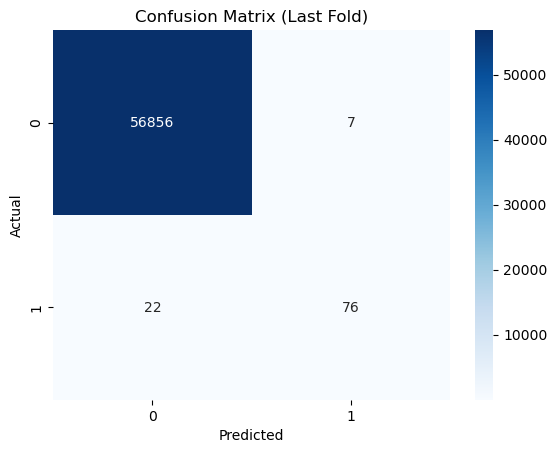

In [40]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Last Fold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

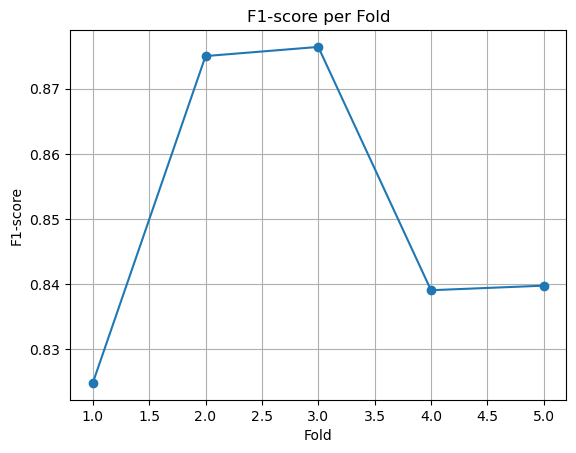

In [42]:

plt.plot(range(1, 6), f1_scores, marker='o')
plt.title('F1-score per Fold')
plt.xlabel('Fold')
plt.ylabel('F1-score')
plt.grid(True)
plt.show()
